# 📊 Exploratory Data Analysis (EDA)

## 🛍️ Project Title
**Amazon Product Sales - Exploratory Data Analysis**

---

## 🎯 Objective
The objective of this project is to explore the cleaned Amazon product sales dataset to uncover meaningful patterns, trends, and insights. This analysis aims to understand product pricing, customer ratings, reviews, discounts, product categories and delivery trends through statistical summaries and visualizations. The findings can help identify factors that influence product popularity and sales performance.

---

## 📁 Dataset Description
The dataset contains cleaned information about Amazon products collected from an e-commerce platform. It includes product details, pricing, discounts, customer ratings, reviews, product categories, delivery details, and other relevant attributes.

### Key Features
- Product Name
- Main Category
- Rating
- Review count
- Unit sold
- Discounted Price
- Original Price
- ***Discount Percentage****
- Best seller
- Delivery Date
- Delivery Day
- Delivery Month
- And other cleaned product-related attributes

The dataset has already undergone data cleaning and preprocessing to handle missing values, inconsistent formats, duplicate records, and incorrect data types.

---

## ❓ Questions to Answer

***Product Analysis***
- Which product categories contain the highest number of products?
- What are the most common product categories?

***Pricing Analysis***
- What is the distribution of discounted prices?
- Which categories have the highest average discounted price?
- Which products receive the highest discounts?
- Is there a relationship between original price and discounted price?

***Rating & Review Analysis***
- How are product ratings distributed?
- Which categories have the highest average ratings?
- Which products have the largest number of ratings and reviews?
- Do highly rated products receive more reviews?
***Discount Analysi***
- Which categories offer the highest discounts?
- Is there a relationship between discount percentage and product ratings?
- Do larger discounts lead to more customer reviews?

***Delivery Analysis***
- Which delivery day occurs most frequently?
- Are products delivered more often in specific months?

***Correlation Analysis***
- Is there a relationship between price and rating?
- Does review count increase with rating count?
- Which numerical features are strongly correlated?

***Overall Insights***
- What are the key trends and patterns in the dataset?
- What business insights can be derived from the analysis?
- What recommendations can improve product performance and customer engagement?

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading Clean Dataset
df = pd.read_csv('C:/Users/Admin/DataScienceCourse/Amazon_Project/data/Interim/amazon_product_sales_cleaned.csv')

In [3]:
# changing datatype
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'])

In [4]:
# overview
df.head()

,product_title,product_category,product_rating,review_count,units_sold_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_couponed,buy_box_availability,delivery_date,delivery_month,delivery_day,image_url,product_url,data_collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,Smartphones,4.6,375,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,September,Monday,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",Smartphones,4.3,2457,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,August,Friday,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",Smartphones,4.6,3044,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,September,Monday,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Headphones & Earbuds,4.6,35882,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,Not Available,NaT,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,Smartphones,4.8,28988,10000.0,72.74,72.74,No Badge,Organic,No Coupon,Not Available,NaT,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29


## Dataset Overview

In [5]:
# Shape
df.shape

(40135, 17)

In [6]:
# columns
df.columns

Index(['product_title', 'product_category', 'product_rating', 'review_count',
       'units_sold_last_month', 'discounted_price', 'original_price',
       'is_best_seller', 'is_sponsored', 'has_couponed',
       'buy_box_availability', 'delivery_date', 'delivery_month',
       'delivery_day', 'image_url', 'product_url', 'data_collected_at'],
      dtype='object')

In [7]:
# Datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40135 entries, 0 to 40134
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   product_title          40135 non-null  object        
 1   product_category       40135 non-null  object        
 2   product_rating         39118 non-null  float64       
 3   review_count           40135 non-null  int64         
 4   units_sold_last_month  30357 non-null  float64       
 5   discounted_price       39993 non-null  float64       
 6   original_price         39993 non-null  float64       
 7   is_best_seller         40135 non-null  object        
 8   is_sponsored           40135 non-null  object        
 9   has_couponed           40135 non-null  object        
 10  buy_box_availability   40135 non-null  object        
 11  delivery_date          30692 non-null  datetime64[ns]
 12  delivery_month         30692 non-null  object        
 13  d

In [8]:
# Missing Values
df.isnull().sum()

product_title               0
product_category            0
product_rating           1017
review_count                0
units_sold_last_month    9778
discounted_price          142
original_price            142
is_best_seller              0
is_sponsored                0
has_couponed                0
buy_box_availability        0
delivery_date            9443
delivery_month           9443
delivery_day             9443
image_url                   0
product_url              2004
data_collected_at           0
dtype: int64

In [9]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

In [10]:
# summary statistics
df.describe()

,product_rating,review_count,units_sold_last_month,discounted_price,original_price,delivery_date,data_collected_at
count,39118.000000,40135.000000,30357.000000,39993.000000,39993.000000,30692,40135
mean,4.408899,2959.789710,1350.085647,207.981149,222.587955,2025-09-04 06:42:02.298970368,2025-08-26 11:31:20.296100864
min,1.000000,0.000000,50.000000,2.160000,2.160000,2025-08-27 00:00:00,2025-08-21 11:14:29
25%,4.200000,76.000000,100.000000,28.990000,30.990000,2025-09-02 00:00:00,2025-08-24 21:56:14
50%,4.500000,336.000000,200.000000,79.990000,85.990000,2025-09-03 00:00:00,2025-08-25 11:26:46
75%,4.700000,1845.000000,400.000000,216.660000,219.000000,2025-09-04 00:00:00,2025-08-29 11:21:10
max,5.000000,865598.000000,100000.000000,4699.000000,5399.000000,2025-09-29 00:00:00,2025-08-30 19:56:33
std,0.383922,13058.868528,6463.762206,356.690530,388.828782,NaN,NaN


## Column Types

- **Numerical** - product_rating , review_count , unit_sold_last_month , discounted_price , original_price 
- **Categorical** - product_category , is_best_seller , is_sponsored , has_couponed , buy_box_availability , delivery_day , delivery_month 
- **datetime** - delivery_date

## Univariate Analysis

### Numerical Columns

#### Product_rating
**conclusions**

- mostly all product has rating greater than 4
- Very few products have low ratings
- The product_rating distribution is highly negatively skewed
- There are no outliers above the upper whisker. But low-rated products are treated as outliers.
- 2 % missing values 

In [11]:
# Statistical Summary (min,max,mean,median,std,quantile)
df['product_rating'].describe()

count    39118.000000
mean         4.408899
std          0.383922
min          1.000000
25%          4.200000
50%          4.500000
75%          4.700000
max          5.000000
Name: product_rating, dtype: float64

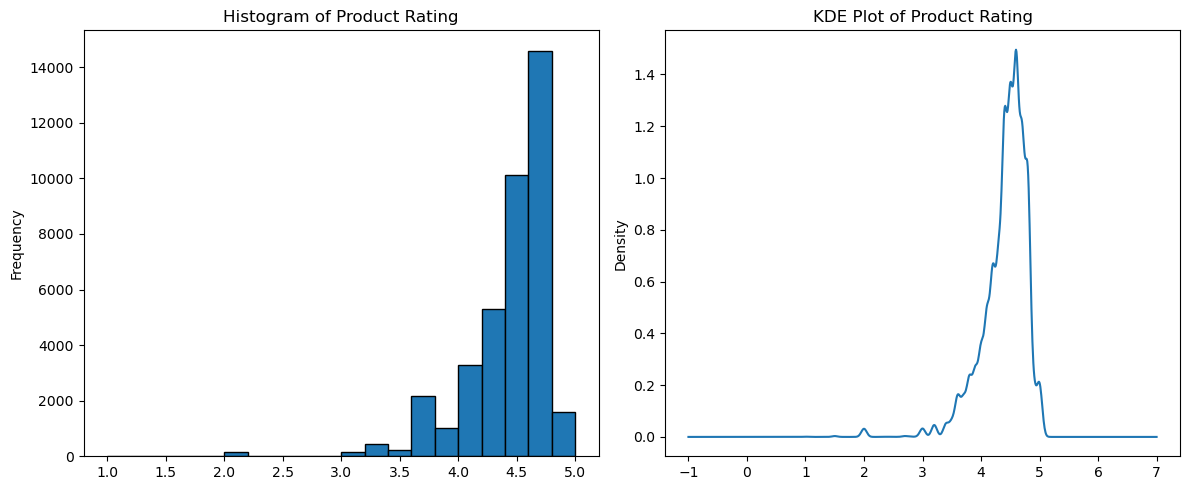

In [83]:
# Distribution Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
df["product_rating"].plot(
    kind="hist",
    bins=20,
    edgecolor="black",
    ax=ax[0],
    title="Histogram of Product Rating"
)

# KDE Plot
df["product_rating"].plot(
    kind="kde",
    ax=ax[1],
    title="KDE Plot of Product Rating"
)

plt.tight_layout()
plt.show()

<Axes: >

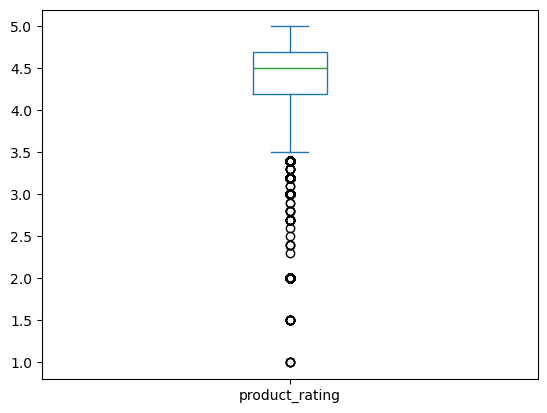

In [13]:
# Box plot
df['product_rating'].plot(kind='box')

In [81]:
# skewness
df['product_rating'].skew()

np.float64(-1.930110770693947)

In [82]:
# Outliers
df[df['product_rating'] < 3.5].shape
# There are no outliers above the upper whisker.
# But low-rated products are treated as outliers.

(767, 17)

In [16]:
# missing values
df['product_rating'].isnull().sum()/len(df['product_rating'])*100

np.float64(2.5339479257505917)

#### Review_count
**conclusions**

- highly skewed data
- no missing value

In [17]:
# Statistical Summary
df['review_count'].describe()

count     40135.000000
mean       2959.789710
std       13058.868528
min           0.000000
25%          76.000000
50%         336.000000
75%        1845.000000
max      865598.000000
Name: review_count, dtype: float64

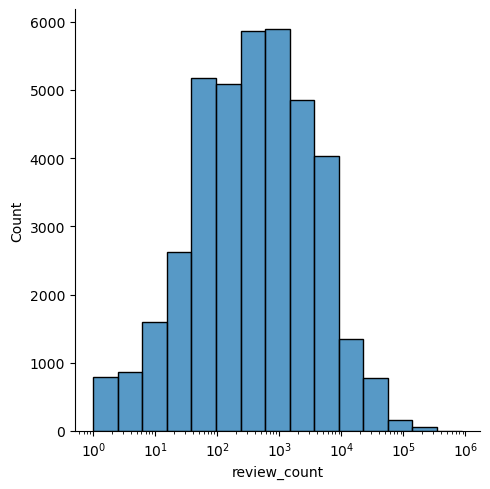

In [80]:
# Distribution Plot
sns.displot(data=df,kind='hist',x='review_count',bins=15,log_scale=True)

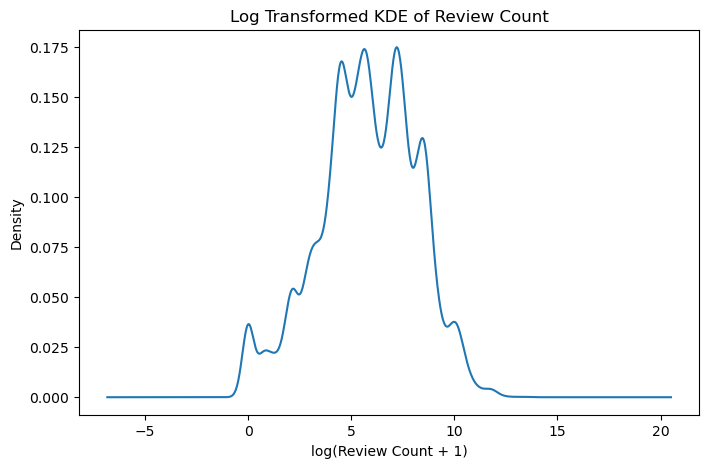

In [19]:
# Log transformation
review_count_log = np.log1p(df["review_count"])
# kde plot
plt.figure(figsize=(8,5))
review_count_log.plot(kind="kde")
plt.title("Log Transformed KDE of Review Count")
plt.xlabel("log(Review Count + 1)")
plt.show()

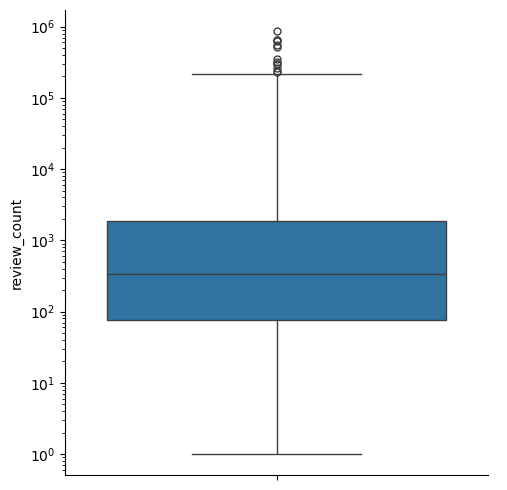

In [20]:
# outliers 
sns.catplot(data=df,kind='box',y='review_count',log_scale=True)

In [79]:
# skewness
df['review_count'].skew()

np.float64(25.037315142693682)

In [22]:
# missing values
df['review_count'].isnull().sum()/len(df['review_count'])*100

np.float64(0.0)

#### units_sold_last_month
**conclusions**

- highly skewed
- outliers present
- 24 % values are missing

In [23]:
# Statistical Summary
df['units_sold_last_month'].describe()

count     30357.000000
mean       1350.085647
std        6463.762206
min          50.000000
25%         100.000000
50%         200.000000
75%         400.000000
max      100000.000000
Name: units_sold_last_month, dtype: float64

Text(0.5, 1.0, 'Log Transformed Distribution of Units Sold')

<Figure size 800x500 with 0 Axes>

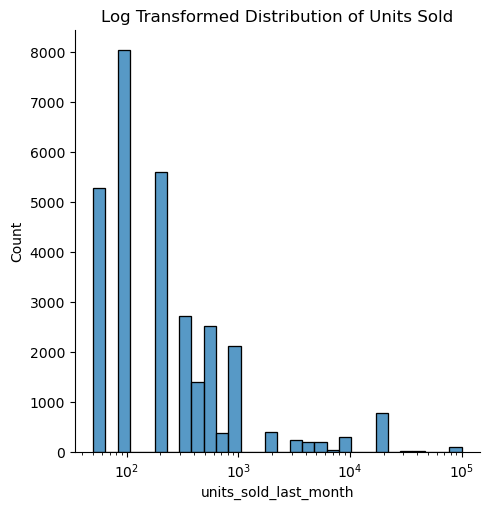

In [78]:
# Distribution Plot
plt.figure(figsize=(8,5))
sns.displot(data=df,kind='hist',x='units_sold_last_month',bins=30,log_scale=True)
plt.title("Log Transformed Distribution of Units Sold")

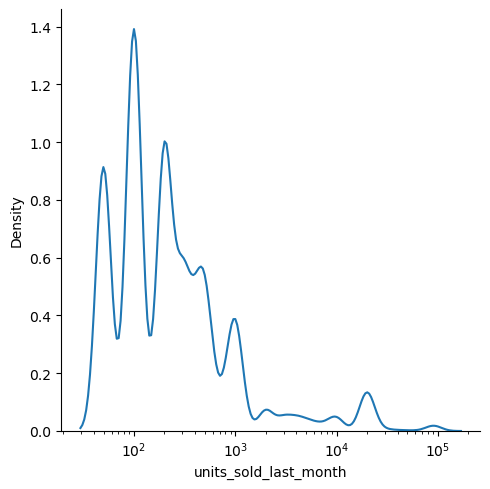

In [25]:
# Kde plot
sns.displot(data=df,kind='kde',x='units_sold_last_month',log_scale=True)

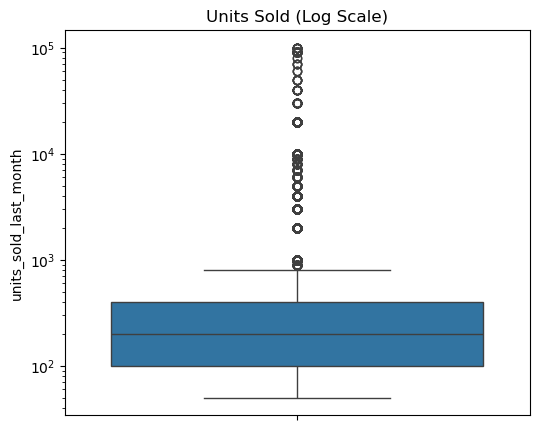

In [26]:
# Box Plot on Log Scale
plt.figure(figsize=(6,5))
sns.boxplot(y=df["units_sold_last_month"])
plt.yscale("log")
plt.title("Units Sold (Log Scale)")
plt.show()

In [77]:
# skewness
df['units_sold_last_month'].skew()

np.float64(10.45759854199748)

In [28]:
# Outliers
df[df['units_sold_last_month']>1000].shape

(2315, 17)

In [76]:
# Missing values
df['units_sold_last_month'].isnull().sum()/len(df['units_sold_last_month'])*100

np.float64(24.362775632241185)

#### discounted_price
**conclusions**

- highly skewed data
- most price range between Rs.0 to 500
- some missing value 0.35%

In [30]:
# Statistical Summary
df['discounted_price'].describe()

count    39993.000000
mean       207.981149
std        356.690530
min          2.160000
25%         28.990000
50%         79.990000
75%        216.660000
max       4699.000000
Name: discounted_price, dtype: float64

Text(0.5, 1.0, 'Log Transformed Distribution of discounted price')

<Figure size 800x500 with 0 Axes>

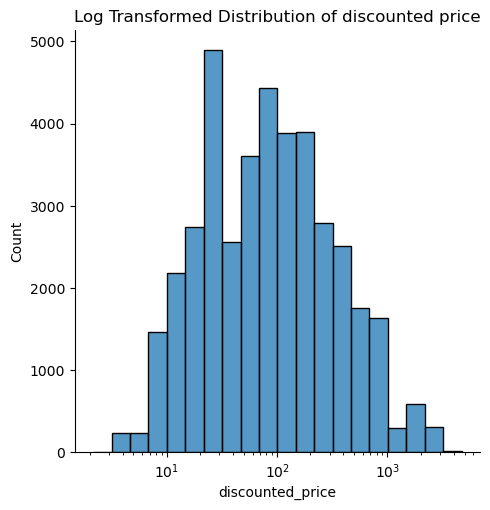

In [31]:
# Distribution Plot
plt.figure(figsize=(8,5))
sns.displot(data=df,kind='hist',x='discounted_price',bins=20,log_scale=True)
plt.title("Log Transformed Distribution of discounted price")

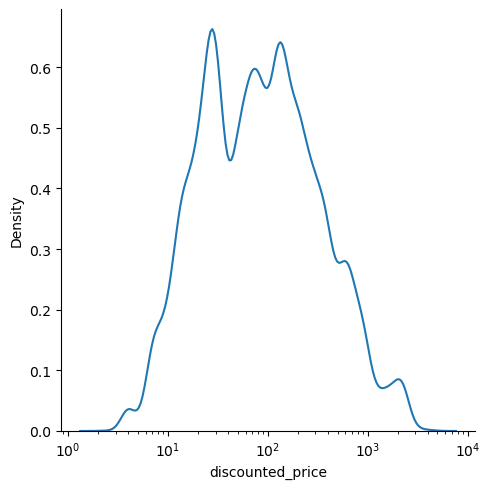

In [75]:
# Kde plot
sns.displot(data=df,kind='kde',x='discounted_price',log_scale=True)

<Axes: >

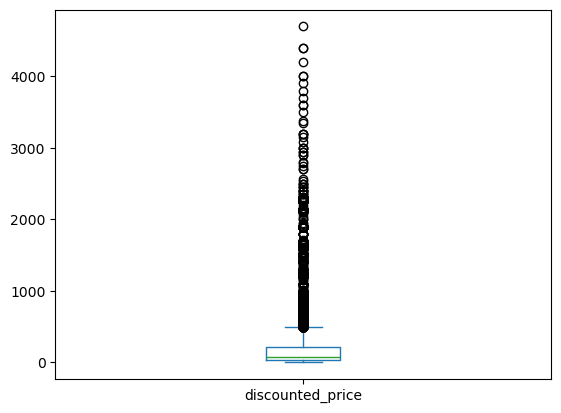

In [33]:
# Box plot
df['discounted_price'].plot(kind='box')

In [34]:
# Price Range Analysis
price_bins = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,
              2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000,
              df['discounted_price'].max()
]
price_labels = ['₹0-250','₹251-500','₹501-750','₹751-1000','₹1001-1250','₹1251-1500','₹1501-1750',
                '₹1751-2000','₹2001-2250','₹2251-2500','₹2501-2750','₹2751-3000','₹3001-3250',
                '₹3251-3500','₹3501-3750','₹3751-4000','Above ₹4000'
]
price_range = pd.cut(
    df['discounted_price'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)
price_range.value_counts().sort_index()

discounted_price
₹0-250         31114
₹251-500        4590
₹501-750        1955
₹751-1000       1142
₹1001-1250       198
₹1251-1500       100
₹1501-1750       267
₹1751-2000       155
₹2001-2250       152
₹2251-2500       287
₹2501-2750         5
₹2751-3000         9
₹3001-3250         5
₹3251-3500         3
₹3501-3750         3
₹3751-4000         4
Above ₹4000        4
Name: count, dtype: int64

In [35]:
# skewness
df['discounted_price'].skew()

np.float64(3.8669334493969187)

In [36]:
# Outliers
df[df['discounted_price'] > 2500].shape

(33, 17)

In [37]:
# missing value
df['discounted_price'].isnull().sum()/len(df['discounted_price'])*100

np.float64(0.35380590507038745)

#### original_price
**conclusions**

- highly skewed data
- most price range between Rs.0 to 500
- some missing value 0.35%

In [38]:
# Statistical Summary
df['original_price'].describe()

count    39993.000000
mean       222.587955
std        388.828782
min          2.160000
25%         30.990000
50%         85.990000
75%        219.000000
max       5399.000000
Name: original_price, dtype: float64

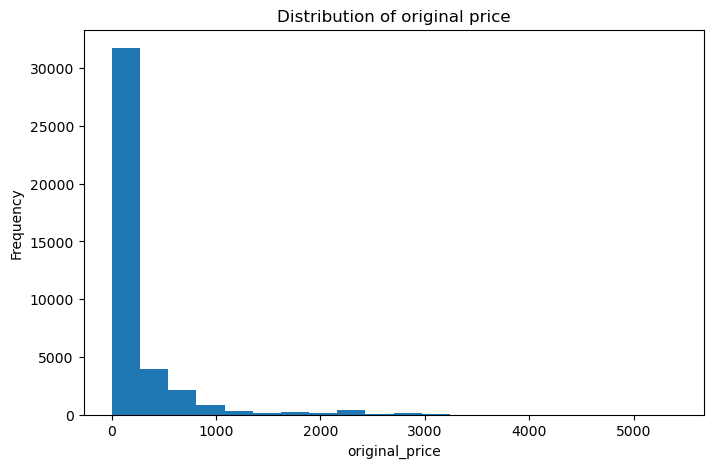

In [56]:
# Distribution Plot
plt.figure(figsize=(8,5))
df['original_price'].plot(kind='hist',bins=20)
plt.title("Distribution of original price")
plt.xlabel("original_price")
plt.show()

<Axes: ylabel='Density'>

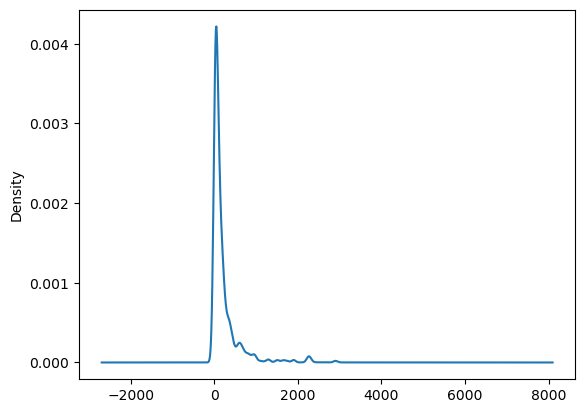

In [58]:
# Kde plot
df['original_price'].plot(kind='kde')

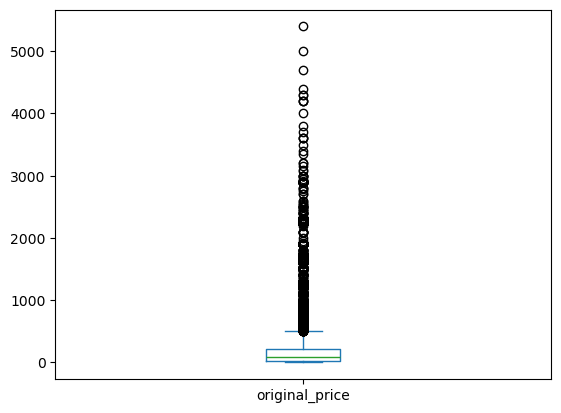

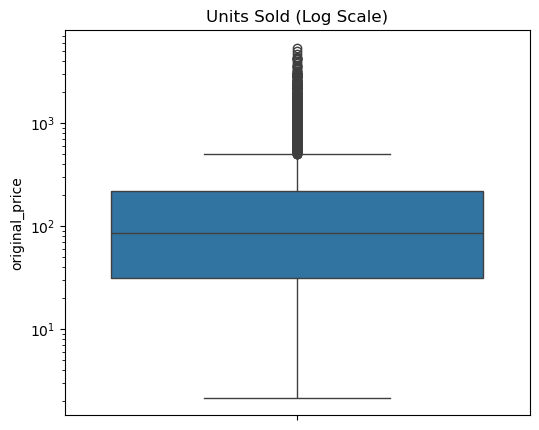

In [63]:
# Box plot
df['original_price'].plot(kind='box')
# Box Plot on Log Scale
plt.figure(figsize=(6,5))
sns.boxplot(y=df["original_price"])
plt.yscale("log")
plt.title("Units Sold (Log Scale)")
plt.show()

In [72]:
# Price Range Analysis
price_bins = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,
              2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000,
              df['original_price'].max()
]
price_labels = ['₹0-250','₹251-500','₹501-750','₹751-1000','₹1001-1250','₹1251-1500','₹1501-1750',
                '₹1751-2000','₹2001-2250','₹2251-2500','₹2501-2750','₹2751-3000','₹3001-3250',
                '₹3251-3500','₹3501-3750','₹3751-4000','Above ₹4000'
]
price_range = pd.cut(
    df['original_price'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)
price_range.value_counts().sort_index()

original_price
₹0-250         30937
₹251-500        4579
₹501-750        1949
₹751-1000       1141
₹1001-1250       129
₹1251-1500       240
₹1501-1750       293
₹1751-2000       153
₹2001-2250       149
₹2251-2500       289
₹2501-2750         9
₹2751-3000       102
₹3001-3250         5
₹3251-3500         3
₹3501-3750         4
₹3751-4000         2
Above ₹4000        9
Name: count, dtype: int64

In [68]:
# Outliers
df[df['discounted_price'] > 2500].shape

(33, 17)

In [74]:
# skewness
df['original_price'].skew()

np.float64(4.001970529477833)

In [73]:
# missing value
df['original_price'].isnull().sum()/len(df['original_price'])*100

np.float64(0.35380590507038745)